<a href="https://colab.research.google.com/github/kithik7/Theoretical_Neuroscience/blob/Ex3_Development_of_Ocular_Dominance/TNS_II_Exercise_3_ocular_dominance_solved.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Development of ocular dominance

During neural development, projection patterns are established both by activity-independent and activity-dependent processes. Whereas the former control initial targeting and coarse mapping, the latter are thought to underlie continued refinement and maintenance of neuronal selectivities and functional cortical maps.


This exercise uses unsupervised Hebbian learning to develop ‘ocular dominance’ (eye preference) in visual cortex.

\\

<div align=center>
<img width=750 src="https://drive.google.com/uc?id=1cTG_3cI6rtQxtLgz1zQO02bi5zIMYPMN"/>
</div>

This figure is taken from Peter Dayan and Larry Abbott's Theoretical Neuroscience, chapter 8 "Unsupervised Learning"

## Left and right eye input

We consider two visual inputs from the left and right eye, $u_L$ and $u_R$, representing sensory neurons of the visual stream.  For simplicity, we assume that input activities are $0$ or $1$ with equal probability, so that the average value is $\langle u_R \rangle = \langle u_L \rangle = 1/2$. Each of these simplified sensory neurons projects to cortical neurons in the early visual cortex (striate cortex, BA 17).

We will evaluate input pairs $(u_R, u_L)$ with different correlations (that is, correlations of activity between the sensory neurons). Specifically, we parametrise the probability table for $u_L$ and $u_R$ as follows:
$$
\begin{array}{c|cc|c}
 & u_R=1 & u_R=0 & p_L\\
 \hline
 u_L=1& \gamma / 4 & 1 / 2 -  \gamma/4 & 1/2 \\
 u_L=0&   1/2-\gamma / 4 &\gamma / 4 & 1/2 \\
 \hline
 p_R &  1/2 &  1/2  & 1
\end{array}
$$
This definition produces *negative* correlations for $0\leq \gamma < 1$, no correlations (independence) for $\gamma = 1$, and *positive* correlations for $1< \gamma \leq 2$.  

## Task A: Input covariance


Choose three values $\gamma_1<1$, $\gamma_2=1$, and $\gamma_3>1$ and compute the corresponding covariance matrices
$$
\textbf{C}_{1,2,3} = \left(\begin{array}{cc} c_S &  c_D \\ c_D &  c_S \end{array} \right)
$$
where
$$
c_S = \langle u_R u_R \rangle - \langle u_R \rangle^2=  \langle u_L u_L \rangle -\ \langle u_L \rangle^2\qquad\qquad c_D = \langle u_R u_L \rangle -  \langle u_R  \langle u_L \rangle
$$



For each value of $\gamma_{1,2,3}$, generate an ensemble of $1000$ input pairs $(u_L, u_R)$ with the appropriate statistics! Numerically compute the covariance matrix for each ensemble and compare with the analytical result above!

For each value of $\gamma_{1,2,3}$, use the provided Matlab function `ShowEigen()` to plot the eigenvectors and eigenvalues of the covariance matrix!

Which eigenvector dominates in case of *positive* and *negative* correlations?  Which dominates in case of *no* correlation?


## Task B: Development with weight saturation

Assume that your two inputs, $u_L$ and $u_R$, project *linearly* and with weights $w_L$ and $w_R$ to an output neuron in visual cortex, so that its activity $v$ is

$$
v = \textbf{u} \cdot \textbf{w} = w_R\,u_R + w_L\,u_L
$$

Assume further that weights $w_R$ and $w_L$ develop according to covariance rule within the range $0 \leq w_{R,L} \leq 1$ (weight saturation):

$$
\tau_w \,\frac{d\textbf{w}}{dt} = \textbf{C} \, \textbf{w}  \qquad\qquad {\rm with} \qquad 0 \leq w_{R,L} \leq 1
$$

$$
\textbf{C} =  \left(\begin{array}{cc} c_S &  c_D \\ c_D &  c_S \end{array} \right)
$$

Write out the dynamic equation of input weights and show that

$$
\tau_w \, \frac{dw_R}{dt} = c_S w_R + c_D w_L
$$
\
$$
\tau_w \, \frac{dw_L}{dt}  = c_D w_R + c_S w_L
$$

Iteratively compute developmental trajectories for different starting points $[w_R(0), w_L(0)]$ in the range of $[0, 0.5]$! Visualize the development in the space of *states*, spanned by $0\leq w_{R,L} \leq 1$! Don't forget to prevent the weights from growing beyond the upper and lower limits! Use $\tau_w=1$ as a unit of time. Simulate for at least 100 units of time with steps no larger than $0.1$ units of time.


##Comparison

Describe the different kinds of development that you observe with covariance matrices obtained from different input statistics (i.e., different values $\gamma_{1,2,3}$)?  How does the development depend on the initial weight values?  

Compare the eigenvectors and eigenvalues of the different covariance matrices!  Along which eigenvector do the input weights grow?  Do weights always grow along the principal eigenvector?  If not, why not?

Conclude by stating the necessary and sufficient conditions for obtaining ocular dominance (i.e., monocular input) with this model!

##Task C: Development with dynamic normalisation

Modify your development rule to include dynamic normalization (Oja rule):

$$
\tau_w \,\frac{d\textbf{w}}{dt} = \textbf{C} \, \textbf{w} - \frac{1}{2} \left( \textbf{w}^T \,  \textbf{C} \, \textbf{w} \right) \textbf{w}
\qquad\qquad\qquad 0 \leq w_{R,L}
$$

Write out the dynamic equation of input weights and show analytically that

$$
\tau_w \, \frac{dw_R}{dt} = \left( c_S w_R + c_D w_L \right) - \frac{1}{2} \left( c_S w_R^2 + 2 c_D w_L w_R + c_s w_L^2\right) w_R
$$

$$
\tau_w \, \frac{dw_L}{dt}  =  \left( c_D w_R + c_S w_L\right)- \frac{1}{2} \left( c_S w_R^2 + 2 c_D w_L w_R + c_s w_L^2\right) w_L
$$

where $\alpha$ = 0.5 (see lecture slides). Iteratively compute developmental trajectories for different starting points $[w_R(0), w_L(0)]$ in the range of $[0.0, 0.5]$! Visualize the development in the space of connection states, spanned by $0\leq w_{R,L} \leq 1$! Use $\tau_w=1$ as a unit of time.  Simulate for at least 200 units with steps no larger than $0.1$ units!

##Comparison

Describe the different kinds of development that you observe with covariance matrices obtained from different input statistics (i.e., different values $\gamma_{1,2,3}$)?  How does the development depend on the initial weight values?  

Compare the eigenvectors and eigenvalues of the different covariance matrices!  Along which eigenvector do the input weights grow?  Do weights always grow along the principal eigenvector?  If not, why not?

Conclude by stating the necessary and sufficient conditions for obtaining ocular dominance (i.e., monocular input) with this model!




In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def show_eigen(C: np.ndarray):
    eigvals, eigvecs = np.linalg.eig(C)

    lC1, lC2 = eigvals
    VC1, VC2 = eigvecs[:, 0] * lC1, eigvecs[:, 1] * lC2

    if VC1[0] < 0 and VC1[1] < 0:
        VC1 = -VC1
    if VC2[0] < 0 and VC2[1] < 0:
        VC2 = -VC2
    if VC1[0] > 0 and VC1[1] < 0:
        VC1 = -VC1
    if VC2[0] > 0 and VC2[1] < 0:
        VC2 = -VC2

    plt.figure()
    plt.plot([0, VC1[0]], [0, VC1[1]], 'r', linewidth=2, label='C1')
    plt.plot([0, VC2[0]], [0, VC2[1]], 'b', linewidth=2, label='C2')

    plt.scatter(0, 0, c='k', s=100)
    plt.scatter(VC1[0], VC1[1], c='r', s=100)
    plt.scatter(VC2[0], VC2[1], c='b', s=100)

    plt.legend(loc='best')
    plt.axis('equal')



gamma: 0.5
Analytical C: 
[[ 0.25  -0.125]
 [-0.125  0.25 ]]
Numerical C: 
[[ 0.2499035 -0.133416 ]
 [-0.133416   0.2499035]]


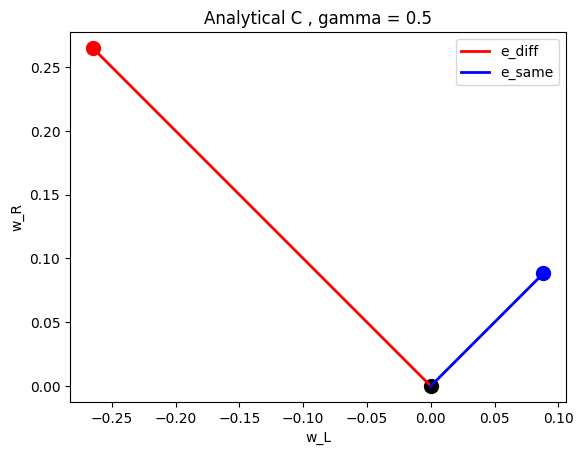

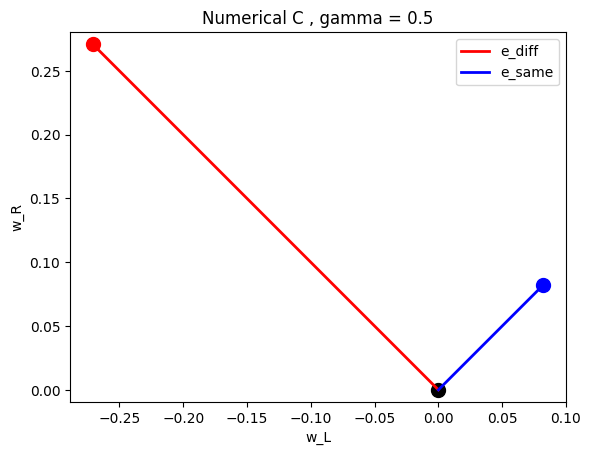

gamma = 0.5, eigenvalues = [0.375 0.125] eigenvectors = [[ 0.70710678  0.70710678]
 [-0.70710678  0.70710678]]
gamma = 0.5, dot product of eigenvectors = 0.0
gamma: 1.0
Analytical C: 
[[0.25 0.  ]
 [0.   0.25]]
Numerical C: 
[[0.249712 0.007   ]
 [0.007    0.249712]]


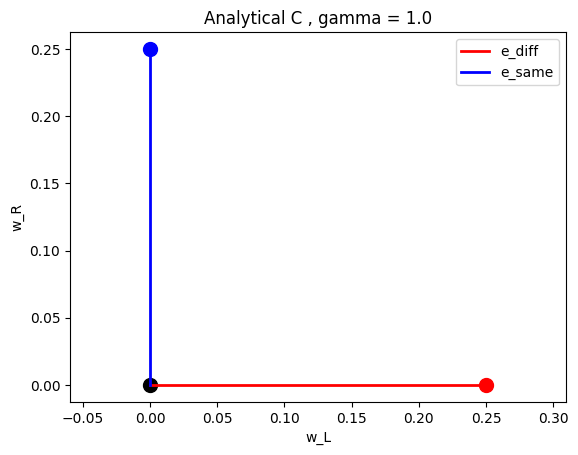

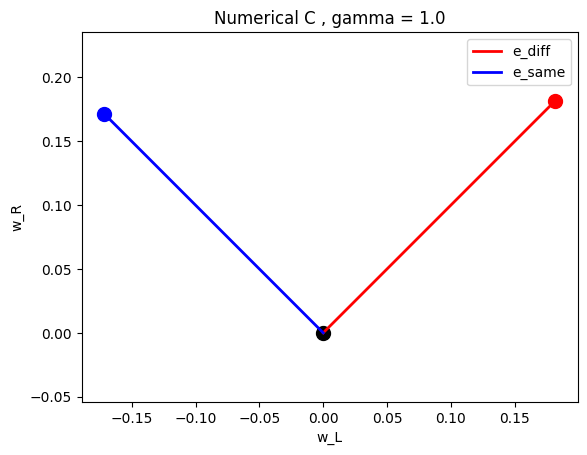

gamma = 1.0, eigenvalues = [0.25 0.25] eigenvectors = [[1. 0.]
 [0. 1.]]
gamma = 1.0, dot product of eigenvectors = 0.0
gamma: 1.5
Analytical C: 
[[0.25  0.125]
 [0.125 0.25 ]]
Numerical C: 
[[0.2499775 0.123518 ]
 [0.123518  0.2499775]]


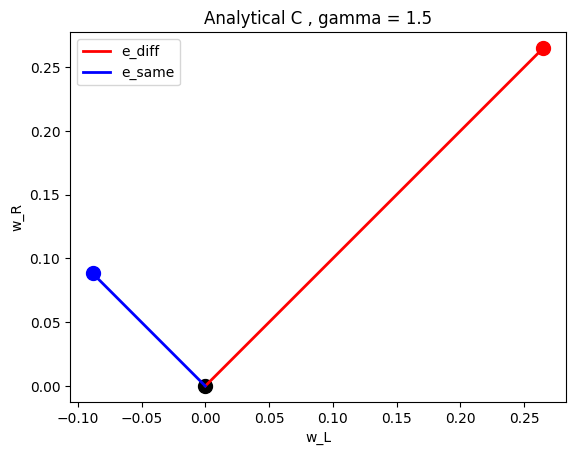

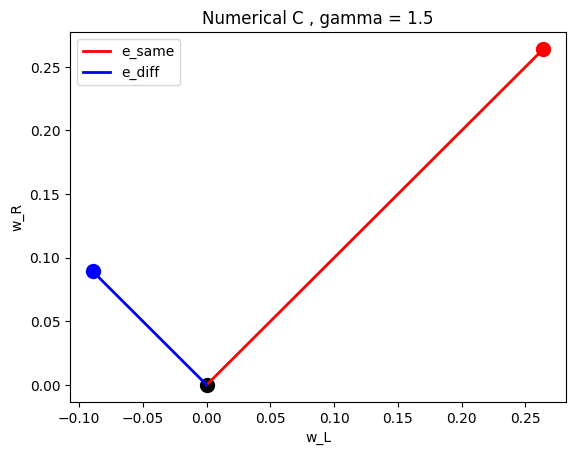

gamma = 1.5, eigenvalues = [0.375 0.125] eigenvectors = [[ 0.70710678 -0.70710678]
 [ 0.70710678  0.70710678]]
gamma = 1.5, dot product of eigenvectors = 0.0
Starting point: [0.1, 0.4]
  t=0.0, w=[0.1 0.4]
  t=10.0, w=[0. 1.]
  t=50.0, w=[0. 1.]
  t=99.9, w=[0. 1.]
  Final: [0. 1.]
Starting point: [0.2, 0.3]
  t=0.0, w=[0.2 0.3]
  t=10.0, w=[0. 1.]
  t=50.0, w=[0. 1.]
  t=99.9, w=[0. 1.]
  Final: [0. 1.]
Starting point: [0.4, 0.1]
  t=0.0, w=[0.4 0.1]
  t=10.0, w=[1. 0.]
  t=50.0, w=[1. 0.]
  t=99.9, w=[1. 0.]
  Final: [1. 0.]
Starting point: [0.3, 0.2]
  t=0.0, w=[0.3 0.2]
  t=10.0, w=[1. 0.]
  t=50.0, w=[1. 0.]
  t=99.9, w=[1. 0.]
  Final: [1. 0.]
Starting point: [0.25, 0.25]
  t=0.0, w=[0.25 0.25]
  t=10.0, w=[0.866 0.866]
  t=50.0, w=[1. 1.]
  t=99.9, w=[1. 1.]
  Final: [1. 1.]


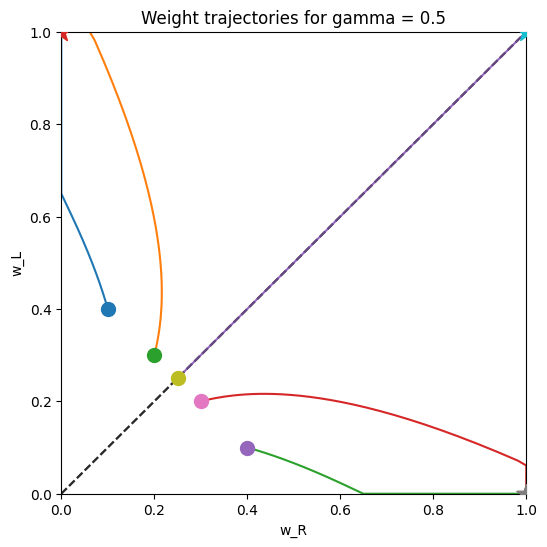

gamma = 0.5, eigenvalues = [0.375 0.125] eigenvectors = [[ 0.70710678  0.70710678]
 [-0.70710678  0.70710678]]


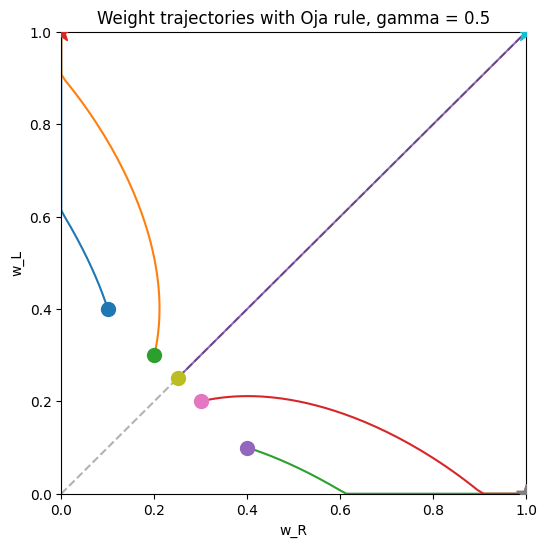

gamma = 0.5, eigenvalues = [0.375 0.125], eigenvectors =
[[ 0.70710678  0.70710678]
 [-0.70710678  0.70710678]]


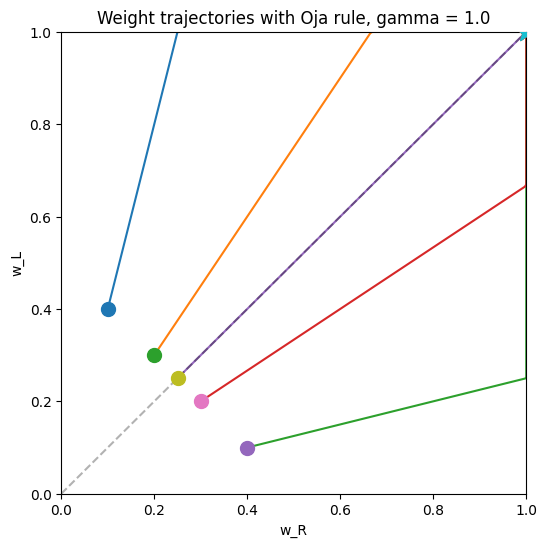

gamma = 1.0, eigenvalues = [0.25 0.25], eigenvectors =
[[1. 0.]
 [0. 1.]]


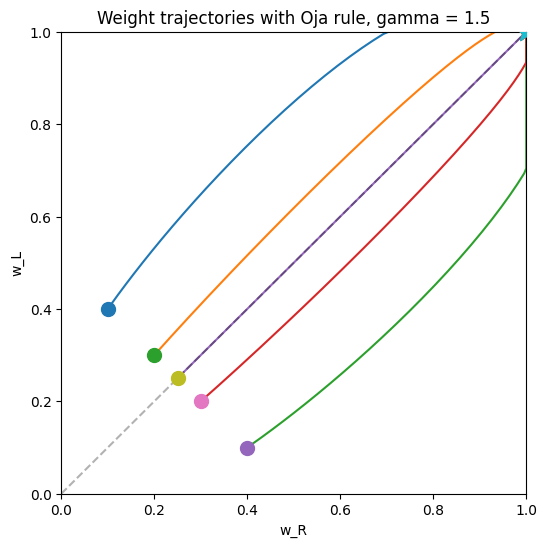

gamma = 1.5, eigenvalues = [0.375 0.125], eigenvectors =
[[ 0.70710678 -0.70710678]
 [ 0.70710678  0.70710678]]


In [2]:
#ex3_ocular_dominance_solved
import numpy as np
import matplotlib.pyplot as plt

#the matplotlib function given to me already
def show_eigen(C: np.ndarray):
    eigvals, eigvecs = np.linalg.eig(C)

    lC1, lC2 = eigvals
    VC1, VC2 = eigvecs[:, 0] * lC1, eigvecs[:, 1] * lC2

    if VC1[0] < 0 and VC1[1] < 0:
        VC1 = -VC1
    if VC2[0] < 0 and VC2[1] < 0:
        VC2 = -VC2
    if VC1[0] > 0 and VC1[1] < 0:
        VC1 = -VC1
    if VC2[0] > 0 and VC2[1] < 0:
        VC2 = -VC2

    plt.figure()
    plt.plot([0, VC1[0]], [0, VC1[1]], 'r', linewidth=2, label='C1')
    plt.plot([0, VC2[0]], [0, VC2[1]], 'b', linewidth=2, label='C2')

    plt.scatter(0, 0, c='k', s=100)
    plt.scatter(VC1[0], VC1[1], c='r', s=100)
    plt.scatter(VC2[0], VC2[1], c='b', s=100)

    plt.legend(loc='best')
    plt.axis('equal')

""" Task A - Input Covariance

Compute the covariance matrices C1, C2 and C3 for three values of gamma
gamma 1 < 1 (anticorrelated inputs), gamma 2 = 1 (uncorrelated/independent) and gamma 3 > 1 (oostively correlated).

where Csame = <uRuR> - <uR>² and Csame is also the same for uLand Cdiff = <uRuL> - <uR><uL>

For each value of gamma, generate an ensemble of 1000 input pairs (uL and uR) with appropriate statistcs. compute
the covariance matrics for each ensemble and compare with the analytical result.
use the function ShowEigen() to plot the eigenvectors and eigenvalues of the covariance matrices.

Which eigenvector dominates in case of positive and negative correlations? Which dominates in case of no correlation?

- there is a constraint that UL and UR take binary values and are on separately 50% of the time.

- there are four combinations of uL and uR, which are (0,0), (0,1), (1,0) and (1,1)heir probabilities are gamma/4, 1/2 - gamma/4, 1/2 - gamma/4 and gamma/4 respectively.

The analytical C Is computed from the formula using gamma where Cdiff = gamma -1 / 4

The numerical C is computed from the ensemble of 1000 input pairs (uL and uR) using the formula for covariance,
which is C = <uRuR> - <uR>² for Csame and C = <uRuL> - <uR><uL> for Cdiff. """


gamma_values = [0.5, 1.0, 1.5]

for gamma in gamma_values:
    #define formula based analytical C matrix
    csame = 1/4
    cdiff = (gamma - 1) / 4
    c_analytical = np.array([[csame, cdiff], [cdiff, csame]])

    #probabilities for each combination of uL and uR

    p00 = gamma/4
    p01 = 0.5 - gamma/4
    p10 = 0.5 - gamma/4
    p11 = gamma/4

    #how does one sample from the distribution above?
    #randomly picking on outcome from the four combinations of uL and uR according to their probabilities.


    probabilities = [p00, p01, p10, p11]

    #generate an ensemble of 1000 input pairs (uL and uR) with appropriate statistics

    ensemble = np.random.multinomial(1000 , probabilities)

    """np.random.multinomial can be thought of in relation to the binomial distribution, but instead of just two outcomes, it can handle multiple outcomes.
    the output of np.random.multinomial is an array of counts for each outcome, which in this case corresponds to the number of times each combination of uL and uR occurs in the
    ensemble of 1000 input pairs. A binomial distribution would only give us the count of successes and failures for a single outcome, while the multinomial distribution gives us counts for multiple outcomes simultaneously.
    binomial = flipping a coin multiple times and counting the number of heads (successes) and tails (failures), while multinomial = rolling a die multiple times and counting the number of times each face appears.
    multionomial has more categories, in our case, the four combinations of uL and uR, while binomial only has two categories (success and failure)."""

    #construct uL and uR arrays based on the counts from multnomial db, ie how many times each combination of uL and uR occurs in the ensemble of 1000 input pairs.

    uL = np.array([0]*ensemble[0] + [0]*ensemble[1] + [1]*ensemble[2] + [1]*ensemble[3])
    uR = np.array([0]*ensemble[0] + [1]*ensemble[1] + [0]*ensemble[2] + [1]*ensemble[3])

    #compute numerical covariance matrix from the ensemble of input pairs

    csame_numerical = 0.5 * (np.mean(uR * uR) - np.mean(uR)**2 + np.mean(uL * uL) - np.mean(uL)**2)
    cdiff_numerical = np.mean(uR * uL) - np.mean(uR)*np.mean(uL)
    c_numerical = np.array([[csame_numerical , cdiff_numerical] , [cdiff_numerical , csame_numerical]])

    print(f"gamma: {gamma}")
    #f strings tells python to not treat the text as a string, but it evaluates it to the point of the curly braces,
    #so it will print the value of gamma instead of the text "gamma: {gamma}"

    print(f'Analytical C: \n{c_analytical}')

    #\n is a newline character, it tells python to move to the next line after printing "Analytical C: "

    print(f'Numerical C: \n{c_numerical}')

    #plot the eigenvectors
    #call showeigen function and use it on c_analytical and c_numerical and plot both to compare!!


    """ how to plot intuitively? - 3 steps:

    Step 1: Where am I building my stage? What is my grid (plt.subplots(rows,cols))?

   - fig , axes = plt.subplots(1,2, fig)
   - or is it just one plot like in this exercises?

    it's like putting together a play on a stage, matplotlib uses an object oriented and a state based logic.
    This just means: I build the structural layout (my stages) and then move from one stage to
    another to draw my content or perform my play

    I have 2 matrices - C(analytical and numerical) I would like to compare them side by side

    So i can divide my large stage (fig) into 2 spaces (subplots, ie. axes[0] on the left and axes[1] on the right)
    plt.subplots(1,2) means I want 1 row and 2 columns in my stage, so python slices my blank stage into a grid that 1 row and 2 columns
    so now, I have 2 spaces on my stage , if i flipped them, 2 rows and 1 column, my stage would be sliced in half and stacked 0 on top and 1 below
    if i had four matrices then i would do 2 rows and 2 columns so my axes would be axes[0,0], axes[0,1], axes[1,0] and axes[1,1]
    and fig size = 10,4 means the width is 10 inches and height is 4 inches ,
    10,2 is also like row and column, because horizontal width comes firstand vertical height comes second"""

    """
    Step 2: where am i drawing my content? (Plt.setcurrentaxes(axes[row,col])) and add title to it with plt.title
    So I want my c_analytical on the left and c numerical on the right, so axes[0] is analytical and axes[1] is numerical

    # plt.sca when switching from axes 0 to axes 1 is like moving the cursor to the right side from left after youre done drawing in one space
    for this task A, since show eigen has its own plt.figure() its easiest to just have two separate figures, in this case we
    do not need to use plt.sca : set current axes to cause its just one image
    plt.sca(axes[0]) #set current axes to the left subplot
    plt.sca(axes[1]) #set current axes to the right subplot

    """

    """
    Step 3: What am i doing with the image? (plt.show() or plt.savefig())
    plt.tight_layout() is used to adjust spacing between subplots to prevent overlap and ensures everything looks real nice and that is what we want"""


    #show_eigen calls its own plt.figure() which creates a new figure, so we cant easily put both subplots,
    # maybe we save both figs separately

    #c_analytical

    show_eigen(c_analytical)
    plt.title(f'Analytical C , gamma = {gamma}')
    plt.xlabel('w_L')
    plt.ylabel('w_R')
    eigvals, eigvecs = np.linalg.eig(c_analytical)
    if eigvecs[0,0] < 0 and eigvecs[1,0] < 0:
        labels = ['e_same' , 'e_diff']
    else:
        labels = ['e_diff' , 'e_same']
    plt.legend(labels)

    plt.show()

    show_eigen(c_numerical)
    plt.title(f'Numerical C , gamma = {gamma}')
    plt.xlabel('w_L')
    plt.ylabel('w_R')
    eigvals, eigvecs = np.linalg.eig(c_analytical)
    if eigvecs[0,0] >0 and eigvecs[1,0] > 0:
        labels = ['e_same' , 'e_diff']
    else:
        labels = ['e_diff' , 'e_same']
    plt.legend(labels)

    plt.show()
#issue is that the plots for diff gammas assign red to C_same or C_diff randomly, so add a legend loop to clarify this

    print(f'gamma = {gamma}, eigenvalues = {eigvals}', f'eigenvectors = {eigvecs}')

    #see dot products for each gamma to see if they are perpendicular or not numerically
    dot_product = np.dot(eigvecs[:,0], eigvecs[:,1])
    print(f'gamma = {gamma}, dot product of eigenvectors = {dot_product}')

#in principle when is less than one, e diff dominates C which means monocular
#for analytical C gamma 0.5 = e_diff dominates , gamma = 1 , perpendicular (tied) and gamma 1.5 = e_diff dominates
#for numerical C, gamma 0.5 = e_diff dominates , gamma = 1 , perpendicular (tied) and gamma 1.5 = e_diff dominates

""" As expected when gamma = 1, we expect no correlation between uL and uR so e_same and e_diff are perpendicular to each other
and the dot product of two perpendicular vectors is zero, so they have the same eigenvalue and neither dominates."""

""" Task B - Weight Saturation- Clipping weights by adding a ceiling limit of 1 and floor limit of 0"""

"""
assume that two inputs uL and uR and they project linearly with weights wL and wR to an output neuron in the visual cortex
so its activity v is
v = u * w = wr * uR + wL * uL
assume further that weights wR and wL develop according to the covariance rule within the range
0<= wR, wL < = 1 (weight saturation) so tw dw/dt = Cw with the former.
and C = ([C_same , C_diff] , [C_diff , C_same]) is the covariance matrix
write out the dynamic equation of input weights and show that
tw dwr/dt =CsameWR + CdiffWL
tw dwL/dt = CdiffWR + CsameWL

Iteratively compute development trajectories for various starting ponts [wR(0) , wL(0)]
in the range [0,0,5]
visualize development of in the space of states spanned by 0 <= wR, wL <= 1
Note dont forget to prevent weights from growing beyond upper and lower limit. Use tw = 1 as a unit of time.
Simulate for atleast 100 units of time with time step of 0.1 units

Describe the different kinds of development that you observe with covariance matrices obtained from
different input statistics (i.e., different values γ1,2,3)? How does the development
depend on the initial weight values?

Compare the eigenvectors and eigenvalues of the different covariance matrices!
Along which eigenvector do the input weights grow? Do weights always grow along the
principal eigenvector? If not, why not?

Conclude by stating the necessary and sufficient conditions for obtaining ocular dominance
(i.e., monocular input) with this model
"""

"""
dynamic equation of input weights written out explicitly as :
w is the weight vector [wR , wL]Tranpose and C = ([csame,cdiff]), [cdiff,csame])
so C*w is basically matrix x vector multiplication which will give me a 2x1 vector same as w

this multiplication written out explicitly is : tw dwr/dt =CsameWR + CdiffWL
tw dwL/dt = CdiffWR + CsameWL

and after each Euler update, i need to clip weights to [0,1] to prevent growing beyond them c
current position w(t) x c*w(t)/tw x delta t

"""
#setup parameters
tau_w = 1.0
T = 100.0
dt = 0.1 #time step of 0.1 units
time_steps = int(T/dt) #100/0.1 = 1000, int() converts result to integer becuase i cant have a fraction as steps
#time steps is basically like asking if clock ticks every 0.1 minutes, and i ran a 100 min race, how many times did it rick?
#answer to that is 100/0.1 = 1000 ticks, so time steps is 1000 cause i need to update weights 1000 times to simulate for 100 units of time
#with time step of 0.1 units (tick frequency)

#choose gamma value - lets do gamme 0.5 (anticorrelated inputs)
gamma = 0.5
csame = 1/4
cdiff = (gamma - 1) / 4
C = np.array([[csame,cdiff] , [cdiff,csame]])

#starting points in range 0-0-5
starting_pts = [[0.1,0.4] , [0.2,0.3] , [0.4 , 0.1] , [0.3 , 0.2] , [0.25 , 0.25]]

plt.figure(figsize = (6,6))

"""the inner loop
1) w0 is the first starting point and w is the current weight vector at t=0
2) w becomes a numpy array ([0.1,0.4])
3)w.copy() screenshots this current weight vector and puts it in a list [w.copy()] which is a
list of weight vector snapshots, without this, the list would have references to same vector w at the end
of iterations"""

for w0 in starting_pts: #outerloop loops through starting points, inner loop updates weights
    w = np.array(w0 , dtype=float) #current weight vector at t=0
    trajectory = [w.copy()] #list of weight vector snapshots

    for t in range(time_steps): #inner loop updates weights for 1000 time steps for each starting point pair
        #euler update
        dw = (C@w)/tau_w * dt #C@w is matrix * vec multiplication
        w = w + dw #update weight vector by adding change in weights to current weight vector

        #weight saturation
        w = np.clip(w , 0, 1) #format is np.clip(variable_array, min_val, max_val)
        trajectory.append(w.copy()) #update trajectory list with new weight vector snapshot after euler update+clip

    trajectory = np.array(trajectory) #convert list of snapshots to an array for plotting
    #trajectory = np.array(trajectory) is outside the inner loop becase we want to
    #convert the list of snapshots to an array after we have finished updating weights for all time steps
    #so that we can plot the trajectory of weights over time for each starting point pair
    print(f'Starting point: {w0}')
    for i in [0, 100, 500, 999]:
        print(f'  t={i*dt:.1f}, w={trajectory[i].round(3)}')

    print(f'  Final: {trajectory[-1].round(3)}')

    plt.plot(trajectory[: , 0] , trajectory[:,1]) #do not wrap this into a list
    plt.scatter(trajectory[0, 0], trajectory[0, 1], marker='o', s=100, zorder=5)
    plt.scatter(trajectory[-1, 0], trajectory[-1, 1], marker='*', s=200, zorder=5)
    plt.plot([0, 1], [0, 1], 'k--', alpha=0.3, label='diagonal')
#trajectory is a 2d array with shape(1001,2) 2 columns wL and wR and 1001 rows for each time step including t=0
# :,0 all rows, column 1 all wR values over time and :,1 all wL values over time

plt.xlabel('w_R')
plt.ylabel('w_L')
plt.title(f'Weight trajectories for gamma = {gamma}')
plt.xlim([0,1]) #() parentheses = do an action, ie set xlim and square bracket is the list of limits
plt.ylim([0,1])
plt.show()

eigvals , eigvecs = np.linalg.eig(C)
print(f'gamma = {gamma}, eigenvalues = {eigvals}', f'eigenvectors = {eigvecs}')


""" gamma = 1.5, eigenvectors = [[ 0.70710678 -0.70710678]
 [ 0.70710678  0.70710678]] eigenvalues = [0.375 0.125]
 - here, esame dominates eigenvalue 0.375 - binocular
 all weights travel together towards (1,1) regardless of starting point

 gamma = 1.0, eigenvectors = [[1. 0.]
 [0. 1.]] eigenvalues = [0.25 0.25] - here, no dominant eigenvector
 (1,0) and (0,1) are standard basis vectors, pependicular to each other
 completely determined by initial conditions

 gamma = 0.5, eigenvectors = [[ 0.70710678  0.70710678]
 [-0.70710678  0.70710678]] eigenvalues = [0.375 0.125] here, e diff dominates:monocular
 which corner depends on intiial conditions, symmetric starting point (0.25,0.25) stays binocular
 weights curve towards corners

 note, the eigvectors printed as two rows, so the first ev is actually 0.707 and -0.707
 """

"""

do weights always grow along the dominant eigenvector with weight sat?
- NO, when weights hit the ceiling or floor, growth is clipped, trajectory cannot continue along eigenvector
direction, it gets forced along the boundary, this is why the symmetric starting point (0.25,0.25) ends at (1,1)
insted of being pushed one way

for ocular dominance with weight saturation
1) anti correlated inputs - gamma less than 1 - so that ediff dominates C
2) asymmetric initial weights - wr must not be equal to wl so the trajectory is pushed towards one corner rather
than staying on the symmetric boundary
"""



""" Task C - Oja's Rule , Development with dynamic normalization of weights

Modify development to include dynamic normalization of weights where:
Tau_w dw/dt = C*w - 0.5 * (w^T * C * w) * w and 0<= Wr, wL

write out the dynamic equation of input weights and anlytically show that
tw dwr/dt =CsameWR + CdiffWL - 0.5 * (w^T * C * w) * wR
tw dwL/dt = CdiffWR + CsameWL - 0.5 * (w^T * C * w) * wL
where alpha =0.5 is a constant of my choosing that controls how strong the correction is
the correction (brakes) in this case basically, is proporitonal to how strongly the weights are already growing

the correction is stormnger as weights gets larger and eventually balance the drive because alpha(wT * C*w)*w
grows quadratically while c*w grows linearly

so iteratively compute developmental trajectories for diff starting points [wr(0), wL(0)] in the range of [0.0, 0.5]

VIsualize the development in the space of connections spanned by 0<=wR , wL <= 1. use Tau_w = 1 and for dt = 0.1 and T = 200

Describe diff developmemnt with diff gamma, how does dev depend on initial weight values?
Compare eigenvec and eigenval of different covariance matrices, do the input weights grow? and do they always
grow along principal eigvec, if not, why not?
conclude by stating necessary and sufficient conditions for obtaining ocular dominance, ie monocular input with this model
"""

#setup parameters
tau_w = 1.0
dt = 0.1
T = 200
time_steps = int(T/dt)

#setup gamma and Covariance matrix with csame and cdiff
for gamma in [0.5, 1.0, 1.5]:
    csame = 1/4
    cdiff = (gamma - 1) / 4
    C = np.array([[csame, cdiff], [cdiff, csame]])

    starting_pts = [[0.1,0.4], [0.2,0.3], [0.4,0.1], [0.3,0.2], [0.25,0.25]]
    plt.figure(figsize=(6,6))

    for w0 in starting_pts:
        w = np.array(w0, dtype=float)
        trajectory = [w.copy()]
        alpha = 0.5

        for t in range(time_steps):
            scalar = w @ C @ w
            dw = (C @ w - alpha * scalar * w) / tau_w * dt
            w = w + dw  # FIXED
            w = np.clip(w, 0, 1)
            trajectory.append(w.copy())

        trajectory = np.array(trajectory)
        plt.plot(trajectory[:,0], trajectory[:,1])
        plt.scatter(trajectory[0,0], trajectory[0,1], marker='o', s=100, zorder=5)
        plt.scatter(trajectory[-1,0], trajectory[-1,1], marker='*', s=200, zorder=5)

    plt.plot([0,1], [0,1], 'k--', alpha=0.3, label='diagonal')
    plt.xlabel('w_R')
    plt.ylabel('w_L')
    plt.xlim([0,1])
    plt.ylim([0,1])
    plt.title(f'Weight trajectories with Oja rule, gamma = {gamma}')
    plt.show()
    eigvals, eigvecs = np.linalg.eig(C)
    print(f'gamma = {gamma}, eigenvalues = {eigvals}, eigenvectors =\n{eigvecs}')
    """
    For gamma = 0.5, eigenvalues = [0.375 0.125], eigenvectors =
    [[ 0.70710678  0.70710678]
    [-0.70710678  0.70710678]]
    - when wL<wR curve towards top left corner (0,1) - left eye dominates
    - when wR>wL curve towards bottom right corner (1,0) - right eze dominates
    - symmetric starting point (0.25,0.25= tavels along the diagonal, still binocular
    - This is the monocular outcome wherein oja rule with covariance rule and
      gamma < 1 produces monocular neurons


    For gamma = 1.0, eigenvalues = [0.25 0.25], eigenvectors =
    [1. 0.]
    [0. 1.]

    standard basis vectors, all travel in different directions, no correlation

    gamma = 1.5, eigenvalues = [0.375 0.125], eigenvectors =
    [[ 0.70710678 -0.70710678]
    [ 0.70710678  0.70710678]]

    -all trajectories curve towards top right corner (1,1), both eyes are equally favored
    - binocular , e same dominates
    - positive correlations means e same dominates and weights grow together


In weight saturation,trajectories hit corners abruptly via straight lines
In dynamic normalization, trajectories curve smoothly towards the dominant eigenvector direction before
hitting the ceiling or boundary


    """